### Build a basic Chatbot with Langgraph (GRAPH API Functionality) 
Important components of langgraph

1.Edge-
2.Nodes
3.State




Graph Api-more easy and best
example of workflow

input -> start ->transcript->output --- get a transcript -> title generator -> content generator---> output


Transcript ->LLM + Prompt -> output

-> edge 
and input etc is node
every node has node implemenation ,perform some node functionality
like take the transcript and generate title


Where does state come in exisance?
State has some variables like transcript variable as soon as i execurte the first node and it will also be used in the 3rd node
--saving the values in states so that the entire graph can use the values
memory can also be used here


Functional Api-



Basic chatbot

start --> node(Chatbot) --> end

add external tools ,integrate,react agents


In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

### if i want to create the chatbot what kind of variables need to be saved in state?execute tthe grph as many number of times ,every conversation saved inside state,keep a variable to add all tha messages,appending the conversations.thats why state graph
### for this use reducers ,add(APPENDS) the messages instead of replacing

In [2]:
class State(TypedDict):
    # Messages have the type list The add_messaages fucntion
    #iN The annotation defines how this state key should be updated
    #(in this case,it appends messages to the list,rather then overwriting it)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os 
from dotenv import load_dotenv

# Load environment variables from .env in project root
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model


llm=ChatGroq(model="llama3-8b-8192")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3 8B', 'status': 'deprecated', 'release_date': '2024-04-18', 'last_updated': '2024-04-18', 'open_weights': True, 'max_input_tokens': 8192, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000025AEB536270>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025AEB536CF0>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
llm=ChatGroq(model="llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000025AEB5CE710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025AEB5CF110>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
#node definition
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"][-1].content)]}

In [9]:
graph_builder = StateGraph(State)
#need to build the graph
graph_builder.add_node("llmchatbot",chatbot)
#add/create edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

#compile the graph
graph=graph_builder.compile()

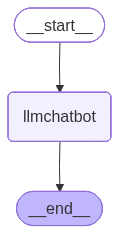

In [10]:
#visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass



In [11]:
from langchain_core.messages import HumanMessage

response=graph.invoke({"messages":"Hi"})

In [12]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [13]:
for event in graph.stream({"messages":"Hi How are you doing today?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?


###  Integrate some external tools?

like provide me the receent AI News--- it cant do on its owns --> Need an external tool for it like Tavily:Web search

chatbot--> tool call-->TOOL NODE --> End 
i can also define some custom tools
How does the LLM know about tools
LLM is th brain for taking decisions llm IS BINDED with tools you have to provide doc string in  the tool 

Can make a tool call based on the specific input

### Chatbot with tools

start --> tool_calling llm -> tools(tavily search ,custom tools)tool node -> end


tool calling llm will decide that wheter it will give answer or make a tol call and tool will provide the output

In [14]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the 

In [16]:
## Custom Function
def multiply(a:int,b:int)->int:
    """Multiply a and b
    
    Args:
        a (int): The first number to multiply.
        b (int): The second number to multiply.
    
    Returns:
        int: The product of a and b.
        """
    return a*b

In [17]:
tools=[tool,multiply]

In [18]:
llm_with_tool=llm.bind_tools(tools)

In [19]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000025AEB5CE710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025AEB5CF110>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search 

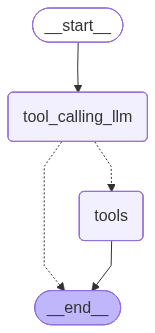

In [21]:
## State Graph with Tools
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
#Binding llm with tools helps it undersstands all tools it have ,when an llm makes a tool call  ,All the tools we have created need to get converted in tool nodes
from langgraph.prebuilt import tools_condition

#Node definintion
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"][-1].content)]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edges
builder.add_edge(START,"tool_calling_llm")
#CONDITIONAL EDGE
builder.add_conditional_edges(
    "tool_calling_llm",
    #if the latest message (result) from assistant is a tool call,then go to the tools_condition routes to tool
    #if the latest message (result) from assistant is not a tool call,then go to the tools_condition routes to END
     tools_condition
)
builder.add_edge("tools",END)


#compile the graph
graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))


In [24]:
response=graph.invoke({"messages":"What is the recent AI News?"})

In [25]:
response["messages"][-1].content

'{"query": "Recent AI News", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/godot-tightens-contribution-policy-to-restrict-ai-code-e58bf90a", "title": "Godot Tightens Contribution Policy to Restrict AI Code - Let\'s Data Science", "score": 0.73981786, "published_date": "Fri, 03 Jul 2026 11:00:06 GMT", "content": "dpl=dpl\\\\_9cwVaWieXr543oix6As2i3Dw6prM\\",\\"precedence\\":\\"next\\",\\"crossOrigin\\":\\"$undefined\\",\\"nonce\\":\\"$undefined\\"}],[\\"$\\",\\"link\\",\\"1\\",{\\"rel\\":\\"stylesheet\\",\\"href\\":\\"/\\\\_next/static/css/a0ef03fe04f76aa4.css? dpl=dpl\\\\_9cwVaWieXr543oix6As2i3Dw6prM\\",\\"precedence\\":\\"next\\",\\"crossOrigin\\":\\"$undefined\\",\\"nonce\\":\\"$undefined\\"}]],[\\"$\\",\\"html\\",null,{\\"lang\\":\\"en\\",\\"data-scroll-behavior\\":\\"smooth\\",\\"suppressHydrationWarning\\":true,\\"children\\":[[\\"$\\",\\"head\\",null,{\\"children\\":[[\\"$\\",\\"link\\",null,{\\"rel\\":\\"preconnec

In [26]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI News?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (rggvd7x5v)
 Call ID: rggvd7x5v
  Args:
    query: Recent AI News
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent AI News", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/godot-tightens-contribution-policy-to-restrict-ai-code-e58bf90a", "title": "Godot Tightens Contribution Policy to Restrict AI Code - Let's Data Science", "score": 0.73981786, "published_date": "Fri, 03 Jul 2026 11:00:06 GMT", "content": "dpl=dpl\\_9cwVaWieXr543oix6As2i3Dw6prM\",\"precedence\":\"next\",\"crossOrigin\":\"$undefined\",\"nonce\":\"$undefined\"}],[\"$\",\"link\",\"1\",{\"rel\":\"stylesheet\",\"href\":\"/\\_next/static/cs

In [31]:
response=graph.invoke({"messages":"What is 48 multiplied by 12 and then multiply by 10? "})

In [32]:
response["messages"][-1].content

'5760'

In [33]:
response=graph.invoke({"messages":"What is the recent AI News  and then multiply 2  by 10? "})

In [ ]:
response["messages"][-1].content
#Now it will give the output of only one node
# so can we return the output back to the llm and llm will be the decision maker and combine the ouput and return in the end
#For this we use a kind of agen called React Agent

'20'

### React Agent
LLM is nothing but the brain responsible for making decisions

and we have some binding tools

i give my natural input AI News+ 5 multiply by 2
break the msgs into two
get the output of one and instead of snding it to end ,sends back to llm
we still have 2nd sentence ,generates response
check if more sentences are left
summarizee the response




1.Act----
2.Observe----
3.Reason------


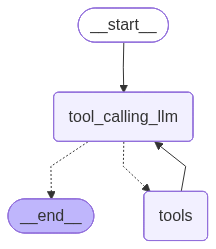

In [36]:
## State Graph with Tools
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
#Binding llm with tools helps it undersstands all tools it have ,when an llm makes a tool call  ,All the tools we have created need to get converted in tool nodes
from langgraph.prebuilt import tools_condition

#Node definintion
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"][-1].content)]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edges
builder.add_edge(START,"tool_calling_llm")
#CONDITIONAL EDGE
builder.add_conditional_edges(
    "tool_calling_llm",
    #if the latest message (result) from assistant is a tool call,then go to the tools_condition routes to tool
    #if the latest message (result) from assistant is not a tool call,then go to the tools_condition routes to END
     tools_condition
)
builder.add_edge("tools","tool_calling_llm")


#compile the graph
graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))


In [38]:
response=graph.invoke({"messages":"What is the recent AI News  and then multiply 2  by 10? "})

KeyboardInterrupt: 

In [39]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI News  and then multiply 2  by 10? 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (wkz556z0b)
 Call ID: wkz556z0b
  Args:
    query: Recent AI News
    search_depth: basic
    time_range: day
    topic: news
  multiply (vzqzk86bj)
 Call ID: vzqzk86bj
  Args:
    a: 2
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent AI News", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/godot-tightens-contribution-policy-to-restrict-ai-code-e58bf90a", "title": "Godot Tightens Contribution Policy to Restrict AI Code - Let's Data Science", "score": 0.73981786, "published_date": "Fri, 03 Jul 2026 11:00:06 GMT", "content": "dpl=dpl\\_9cwVaWieXr543oix6As2i3Dw6prM\",\"precedence\":\"next\",\"crossOri